# Hierarchical Clustering - Mall Customers

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA


In [5]:
df = pd.read_csv("Mall_Customers.csv")
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.isnull().sum()
#check for missing values


,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#Feature scaling

### Dendrogram
Build the dendrogram first to decide how many clusters to use.

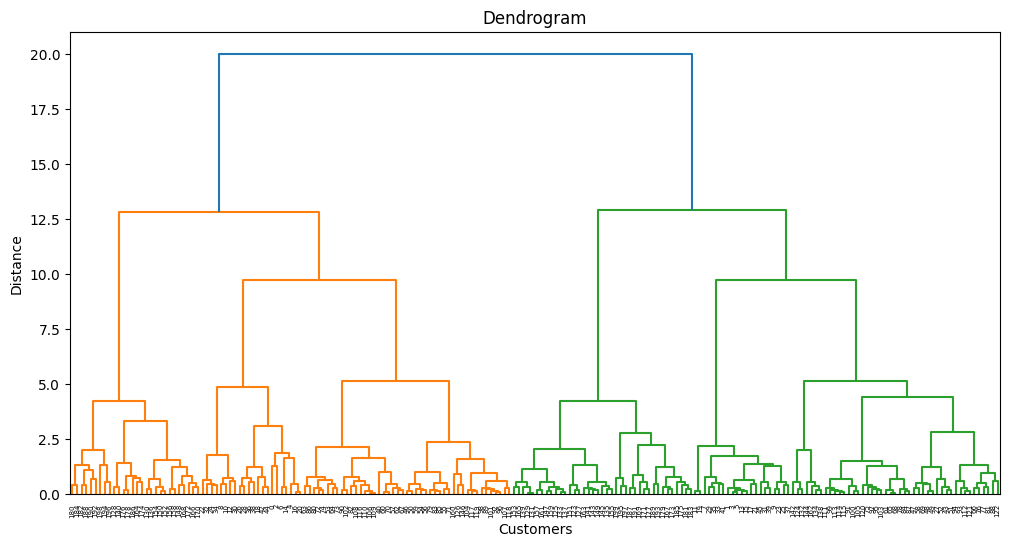

In [8]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()


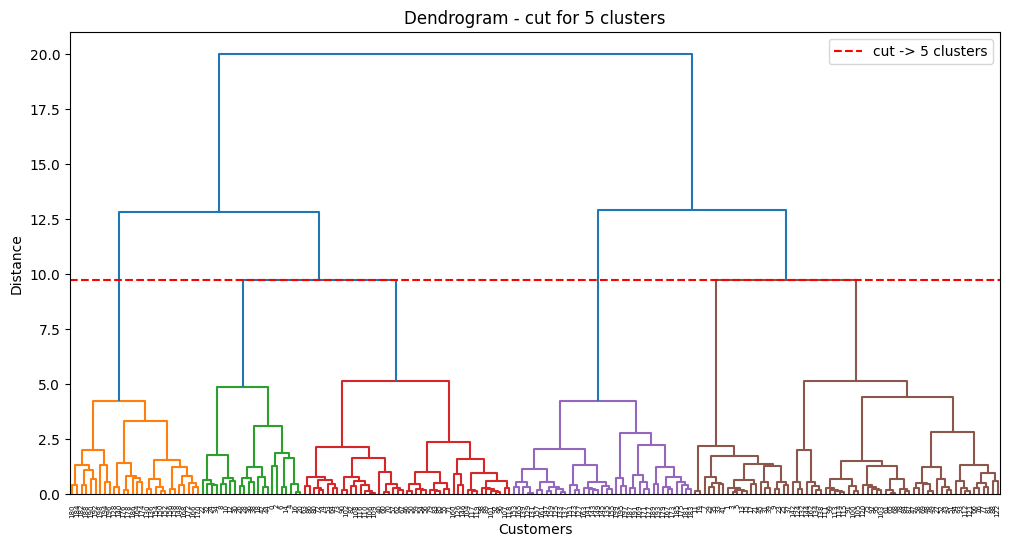

In [22]:
#same dendrogram but with a line showing where we cut for 5 clusters
plt.figure(figsize=(12,6))
dendrogram(Z, color_threshold=9.73)
plt.axhline(y=9.73, color='red', linestyle='--', label='cut -> 5 clusters')
plt.title("Dendrogram - cut for 5 clusters")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.legend()
plt.show()

Looking at the dendrogram, cutting around 5 clusters looks like a good spot (big vertical gap before that merge). Next we check with silhouette score to confirm.

In [10]:
#check silhouette score for a few different k values
scores = []

for k in range(2,9):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print("k =", k, "-> silhouette score:", round(score,3))


k = 2 -> silhouette score: 0.318
k = 3 -> silhouette score: 0.321
k = 4 -> silhouette score: 0.361
k = 5 -> silhouette score: 0.39
k = 6 -> silhouette score: 0.42
k = 7 -> silhouette score: 0.398
k = 8 -> silhouette score: 0.366


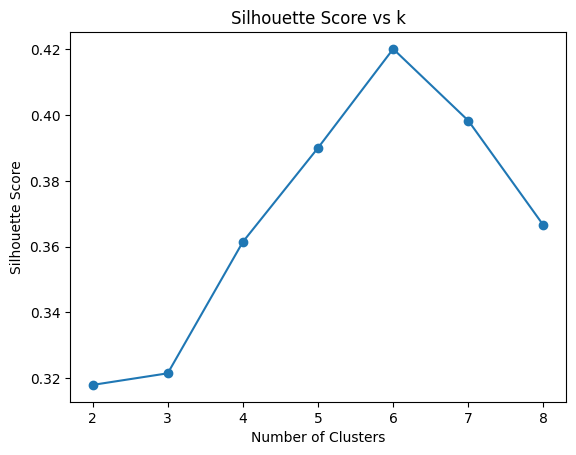

In [11]:
plt.plot(range(2,9), scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()


k=5 matches the dendrogram gap and has a good silhouette score, so going with n_clusters=5.

In [12]:
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
clusters_hc = hc.fit_predict(X_scaled)

df['Cluster'] = clusters_hc


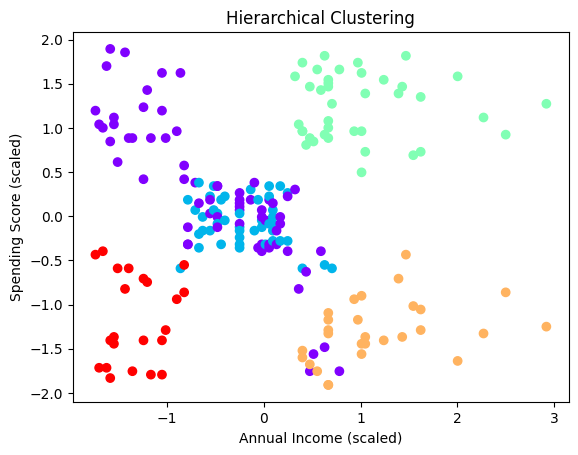

In [13]:
plt.scatter(X_scaled[:,1], X_scaled[:,2], c=clusters_hc, cmap="rainbow")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Hierarchical Clustering")
plt.show()


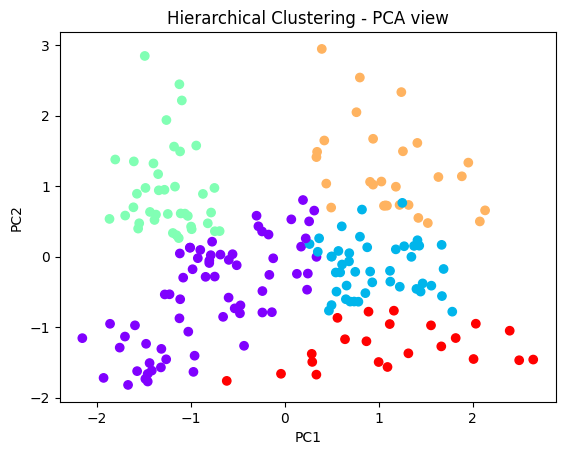

0.7757454566976747


In [17]:
#PCA view using all 3 features
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_hc, cmap="rainbow")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clustering - PCA view")
plt.show()

print(pca.explained_variance_ratio_.sum()) #display saved data.  0.22 is lost

In [15]:
#Evaluate with Silhouette Score
score = silhouette_score(X_scaled, clusters_hc)
print("Silhouette Score:", score)


Silhouette Score: 0.39002826186267214


In [16]:
#average feature values per cluster, to describe the groups
df.groupby('Cluster')[features].mean().round(1)


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,26.6,47.4,56.8
1,56.4,55.3,48.4
2,32.7,86.5,82.1
3,43.9,91.3,16.7
4,44.3,25.8,20.3


Cluster summary (roughly):
- high income, high spending -> best customers
- high income, low spending -> not spending much, could use offers
- low income, high spending -> spends a lot for their income
- low income, low spending -> careful spenders
- average income, average spending -> the "middle" group
